In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import torch
import numpy as np
import nn4n.nn
from matplotlib import pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

N, C = 512, 100
model_cfg = {
            "input_dim":    C,
            "hidden_dim":   N,
            'output_dim':   C,
            "alpha":        0.01,
            "learn_alpha":  False,
            "preact_noise": 0.1,
            "postact_noise":0.1
            }


rnn = nn4n.nn.RNN(
      # Input laters (multiple recurrent layers)
      recurrent_layers=[# 1st recurrent layer
                        nn4n.nn.RecurrentLayer(
                        projection_layer=nn4n.nn.LinearLayer(
                                         input_dim=model_cfg["input_dim"],
                                         output_dim=model_cfg["hidden_dim"]
                                         ),
                        leaky_layer=nn4n.nn.LeakyLinearLayer(
                                    # input_dim=model_cfg["hidden_dim"],
                                    # output_dim=model_cfg["hidden_dim"],
                                    # ----------------------------------------
                                    linear_layer=nn4n.nn.LinearLayer(
                                        input_dim=model_cfg["hidden_dim"],
                                        output_dim=model_cfg["hidden_dim"]),
                                    # ----------------------------------------
                                    activation=torch.nn.ReLU(),
                                    alpha=model_cfg["alpha"],
                                    learn_alpha=model_cfg["learn_alpha"],
                                    preact_noise=model_cfg["preact_noise"],
                                    postact_noise=model_cfg["postact_noise"]
                                    )
                        )
                        # 2nd recurrent layer (None)
                        ],
      # Output layer
      readout_layer=nn4n.nn.LinearLayer(
                    input_dim=model_cfg["hidden_dim"],
                    output_dim=model_cfg["output_dim"]
                    )
      )
rnn.to(device)

optimizer = torch.optim.Adam(rnn.parameters(), lr=0.0005) 

Using device: mps


In [3]:
load_data_type = '2TS'
data = np.load(f'../../data/{load_data_type}.npy', allow_pickle=True).item()
test_inputs = data['test_inputs']
hs = data['test_hidden_states']
print(test_inputs.shape, hs.shape)

(7, 200, 100) (7, 200, 512)


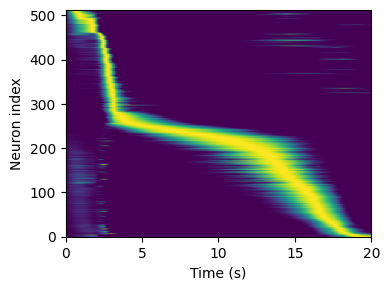

In [4]:
avg_fr = hs.mean(axis=0)
norm_fr = np.zeros_like(avg_fr)
for n in range(avg_fr.shape[1]):
    norm_fr[:, n] = (avg_fr[:, n]-np.min(avg_fr[:, n]))/(np.max(avg_fr[:, n])-np.min(avg_fr[:, n]))
del avg_fr  
# Sort avg_fr by the time of peak firing rate
peak_times = np.argmax(norm_fr, axis=0)
indices = np.argsort(peak_times)
fig, ax = plt.subplots(figsize=(4,3))
plt.imshow(norm_fr[:,indices].T, aspect='auto', origin='upper', extent=[0, norm_fr.shape[0]/10, 0, norm_fr.shape[1]])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Neuron index')
plt.tight_layout()

## Vis trained $W_{rc}$ and idealised $W_{rc}$

In [5]:
# Load model weights 
model_dict = torch.load(f'../../model/{load_data_type}.pth', map_location=device)

Wrc_trained = model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'].cpu().numpy()

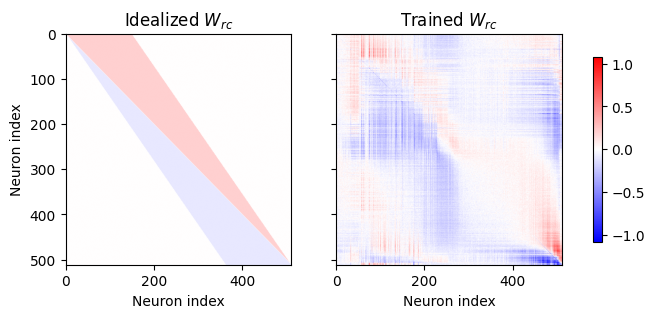

In [6]:
Wrc_reord = Wrc_trained[:, indices][indices]

# Create a recurrent weight matrix
Wrc = np.zeros((N,N))
Delta, gain, loss = 150, 0.2, -0.1
# Set up limits for each row
limits1 = np.linspace(Delta, 0, N, dtype=int)
limits2 = np.linspace(0, Delta, N, dtype=int)
for i in range(N):
    for j in range(N):
        if j > i and j < (i + limits1[i]):
            Wrc[i,j] = gain
        if j < i and j > (i - limits2[i]):
            Wrc[i,j] = loss
    
# Plot the Wrc matrix
from matplotlib import pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
vmin = min(Wrc.min(), Wrc_reord.T.min())
vmax = max(Wrc.max(), Wrc_reord.T.max())
abs = min(np.abs(vmin), np.abs(vmax))
im = axes[0].imshow(Wrc, cmap='bwr', vmin=-abs, vmax=abs, aspect='auto')
axes[1].imshow(Wrc_reord.T, cmap='bwr', vmin=-abs, vmax=abs, aspect='auto')
axes[0].set_xlabel('Neuron index')
axes[0].set_ylabel('Neuron index')
axes[1].set_xlabel('Neuron index')
axes[0].set_title(r'Idealized $W_{rc}$')
axes[1].set_title(r'Trained $W_{rc}$')
fig.colorbar(im, ax=axes, shrink=0.8)
plt.savefig('Wrc_comparison.png', dpi=500, bbox_inches='tight', transparent=False)

## Reorder $W_{out}$ and $W_{rc}$ simultaneously

In [7]:
trained_brc = model_dict['recurrent_layers.0.leaky_layer.linear_layer.bias'].cpu().numpy()

Win_trained = model_dict['readout_layer.weight'].cpu().numpy()
trained_bin = model_dict['readout_layer.bias'].cpu().numpy()
print(Win_trained.shape)

Wout_trained = model_dict['recurrent_layers.0.projection_layer.weight'].cpu().numpy()
trained_bout = model_dict['recurrent_layers.0.projection_layer.bias'].cpu().numpy()   
print(Wout_trained.shape)

(100, 512)
(512, 100)


In [8]:
# # Set 1
# Win_reord = Win_trained[:, indices]
# Wrc_reord = Wrc_trained[indices][:, indices]
# Wout_reord = Wout_trained[indices]

# Set 3
Win_reord = Win_trained
Wrc_reord = Wrc_trained[indices][:, indices]
Wout_reord = Wout_trained[indices]

In [9]:
# ------------------------------ Modify the idealised weights ------------------------------
model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'] = torch.from_numpy(Wrc_reord.astype(np.float32)).to(device)
model_dict['readout_layer.weight'] = torch.from_numpy(Win_reord.astype(np.float32)).to(device)
model_dict['recurrent_layers.0.projection_layer.weight'] = torch.from_numpy(Wout_reord.astype(np.float32)).to(device)

In [10]:
rnn.load_state_dict(model_dict)
rnn.eval()
test_inputs = torch.from_numpy(test_inputs.astype(np.float32)).to(device)
with torch.no_grad():
    test_outputs_from_RNN, hidden_states_from_RNN = rnn(test_inputs)
test_outputs = test_outputs_from_RNN.cpu().numpy()
hidden_states = hidden_states_from_RNN[0].cpu().numpy()
avg_fr = np.mean(hidden_states, axis=0)

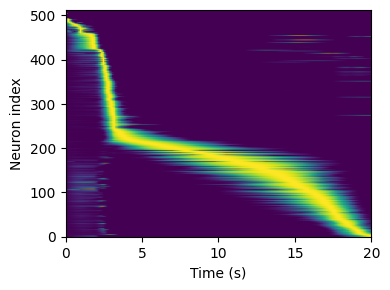

In [11]:
fig, ax = plt.subplots(figsize=(4,3))
norm_fr = np.zeros_like(avg_fr)
for n in range(avg_fr.shape[1]):
    if np.max(avg_fr[:, n]) - np.min(avg_fr[:, n]) == 0:
        norm_fr[:, n] = 0
    else:
        norm_fr[:, n] = (avg_fr[:, n]-np.min(avg_fr[:, n]))/(np.max(avg_fr[:, n])-np.min(avg_fr[:, n]))
del avg_fr  
# Sort avg_fr by the time of peak firing rate
peak_times = np.argmax(norm_fr, axis=0)
indices = np.argsort(peak_times)
plt.imshow(norm_fr[:,indices].T, aspect='auto', origin='upper', extent=[0, norm_fr.shape[0]/10, 0, norm_fr.shape[1]])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Neuron index')
plt.tight_layout()

## Reorder $W_{in}$ and $W_{rc}$ simultaneously

In [12]:
# Set 2
Win_reord = Win_trained[:, indices]
Wrc_reord = Wrc_trained[indices][:, indices]
Wout_reord = Wout_trained

In [13]:
# ------------------------------ Modify the idealised weights ------------------------------
model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'] = torch.from_numpy(Wrc_reord.astype(np.float32)).to(device)
model_dict['readout_layer.weight'] = torch.from_numpy(Win_reord.astype(np.float32)).to(device)
model_dict['recurrent_layers.0.projection_layer.weight'] = torch.from_numpy(Wout_reord.astype(np.float32)).to(device)

In [14]:
rnn.load_state_dict(model_dict)
rnn.eval()
with torch.no_grad():
    test_outputs_from_RNN, hidden_states_from_RNN = rnn(test_inputs)
test_outputs = test_outputs_from_RNN.cpu().numpy()
hidden_states = hidden_states_from_RNN[0].cpu().numpy()
avg_fr = np.mean(hidden_states, axis=0)

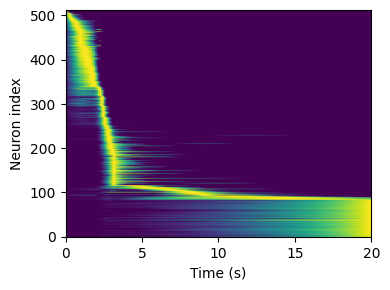

In [15]:
fig, ax = plt.subplots(figsize=(4,3))
norm_fr = np.zeros_like(avg_fr)
for n in range(avg_fr.shape[1]):
    if np.max(avg_fr[:, n]) - np.min(avg_fr[:, n]) == 0:
        norm_fr[:, n] = 0
    else:
        norm_fr[:, n] = (avg_fr[:, n]-np.min(avg_fr[:, n]))/(np.max(avg_fr[:, n])-np.min(avg_fr[:, n]))
del avg_fr  
# Sort avg_fr by the time of peak firing rate
peak_times = np.argmax(norm_fr, axis=0)
indices = np.argsort(peak_times)
plt.imshow(norm_fr[:,indices].T, aspect='auto', origin='upper', extent=[0, norm_fr.shape[0]/10, 0, norm_fr.shape[1]])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Neuron index')
plt.tight_layout()

## Reorder $W_{rc}$ only

In [16]:
Win_reord = Win_trained
Wrc_reord = Wrc_trained[indices][:, indices]
Wout_reord = Wout_trained

In [17]:
# ------------------------------ Modify the idealised weights ------------------------------
model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'] = torch.from_numpy(Wrc_reord.astype(np.float32)).to(device)
model_dict['readout_layer.weight'] = torch.from_numpy(Win_reord.astype(np.float32)).to(device)
model_dict['recurrent_layers.0.projection_layer.weight'] = torch.from_numpy(Wout_reord.astype(np.float32)).to(device)

In [18]:
rnn.load_state_dict(model_dict)
rnn.eval()
with torch.no_grad():
    test_outputs_from_RNN, hidden_states_from_RNN = rnn(test_inputs)
test_outputs = test_outputs_from_RNN.cpu().numpy()
hidden_states = hidden_states_from_RNN[0].cpu().numpy()
avg_fr = np.mean(hidden_states, axis=0)

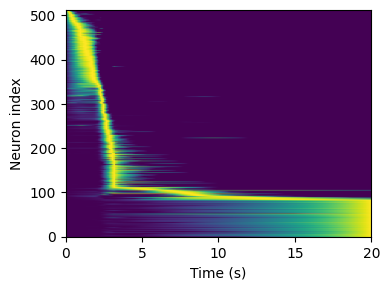

In [19]:
fig, ax = plt.subplots(figsize=(4,3))
norm_fr = np.zeros_like(avg_fr)
for n in range(avg_fr.shape[1]):
    if np.max(avg_fr[:, n]) - np.min(avg_fr[:, n]) == 0:
        norm_fr[:, n] = 0
    else:
        norm_fr[:, n] = (avg_fr[:, n]-np.min(avg_fr[:, n]))/(np.max(avg_fr[:, n])-np.min(avg_fr[:, n]))
del avg_fr  
# Sort avg_fr by the time of peak firing rate
peak_times = np.argmax(norm_fr, axis=0)
indices = np.argsort(peak_times)
plt.imshow(norm_fr[:,indices].T, aspect='auto', origin='upper', extent=[0, norm_fr.shape[0]/10, 0, norm_fr.shape[1]])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Neuron index')
plt.tight_layout()

## Substitute $W_{rc}$ with handcrafted $W_{rc}$

In [20]:
Win_reord = Win_trained[:, indices]
Wrc_reord = np.load('Wrc_theory.npy')
Wout_reord = Wout_trained[indices]

In [21]:
# ------------------------------ Modify the idealised weights ------------------------------
model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'] = torch.from_numpy(Wrc_reord.astype(np.float32)).to(device)
model_dict['readout_layer.weight'] = torch.from_numpy(Win_reord.astype(np.float32)).to(device)
model_dict['recurrent_layers.0.projection_layer.weight'] = torch.from_numpy(Wout_reord.astype(np.float32)).to(device)

In [22]:
rnn.load_state_dict(model_dict)
rnn.eval()
with torch.no_grad():
    test_outputs_from_RNN, hidden_states_from_RNN = rnn(test_inputs)
test_outputs = test_outputs_from_RNN.cpu().numpy()
hidden_states = hidden_states_from_RNN[0].cpu().numpy()
avg_fr = np.mean(hidden_states, axis=0)

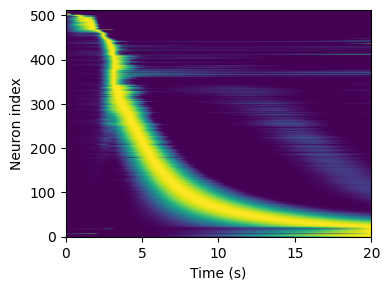

In [23]:
fig, ax = plt.subplots(figsize=(4,3))
norm_fr = np.zeros_like(avg_fr)
for n in range(avg_fr.shape[1]):
    if np.max(avg_fr[:, n]) - np.min(avg_fr[:, n]) == 0:
        norm_fr[:, n] = 0
    else:
        norm_fr[:, n] = (avg_fr[:, n]-np.min(avg_fr[:, n]))/(np.max(avg_fr[:, n])-np.min(avg_fr[:, n]))
del avg_fr  
# Sort avg_fr by the time of peak firing rate
peak_times = np.argmax(norm_fr, axis=0)
indices = np.argsort(peak_times)
plt.imshow(norm_fr[:,indices].T, aspect='auto', origin='upper', extent=[0, norm_fr.shape[0]/10, 0, norm_fr.shape[1]])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Neuron index')
plt.tight_layout()